In [1]:
# Library Import
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Loading Data into the Model
df = pd.read_csv("../data/data.csv")
df.head()

,record_id,machine_id,machine_type,temperature_c,vibration_mms,running_hours,pressure_bar,sound_db,status
0,1,M001,Motor,49.03,1.209,515.6,3.899,60.35,Normal
1,2,M015,Fan,47.25,4.078,3820.1,3.030,63.29,Normal
2,3,M009,Pump,68.27,1.954,4906.8,3.200,64.22,Normal
3,4,M008,Pump,55.97,1.777,4113.7,3.015,60.40,Normal
4,5,M015,Conveyor,55.25,3.994,3467.9,2.913,64.92,Normal


In [3]:
print(f"Shape: {df.shape}")

Shape: (12000, 9)


In [4]:
print("\nDetailed Info:\n")
df.info()


Detailed Info:

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   record_id      12000 non-null  int64  
 1   machine_id     12000 non-null  str    
 2   machine_type   12000 non-null  str    
 3   temperature_c  12000 non-null  float64
 4   vibration_mms  12000 non-null  float64
 5   running_hours  12000 non-null  float64
 6   pressure_bar   12000 non-null  float64
 7   sound_db       12000 non-null  float64
 8   status         12000 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.0 MB


In [5]:
print(f"\nClass distribution:")
print(df["status"].value_counts())


Class distribution:
status
Normal     8412
Warning    2385
Fault      1203
Name: count, dtype: int64


In [6]:
print(f"\nMachine types: {df['machine_type'].unique()}")
print(f"\nMachine ID: {df['machine_id'].unique()}")



Machine types: <ArrowStringArray>
['Motor', 'Fan', 'Pump', 'Conveyor', 'Compressor']
Length: 5, dtype: str

Machine ID: <ArrowStringArray>
['M001', 'M015', 'M009', 'M008', 'M007', 'M017', 'M018', 'M019', 'M002',
 'M014', 'M013', 'M004', 'M003', 'M010', 'M011', 'M006', 'M012', 'M005',
 'M020', 'M016']
Length: 20, dtype: str


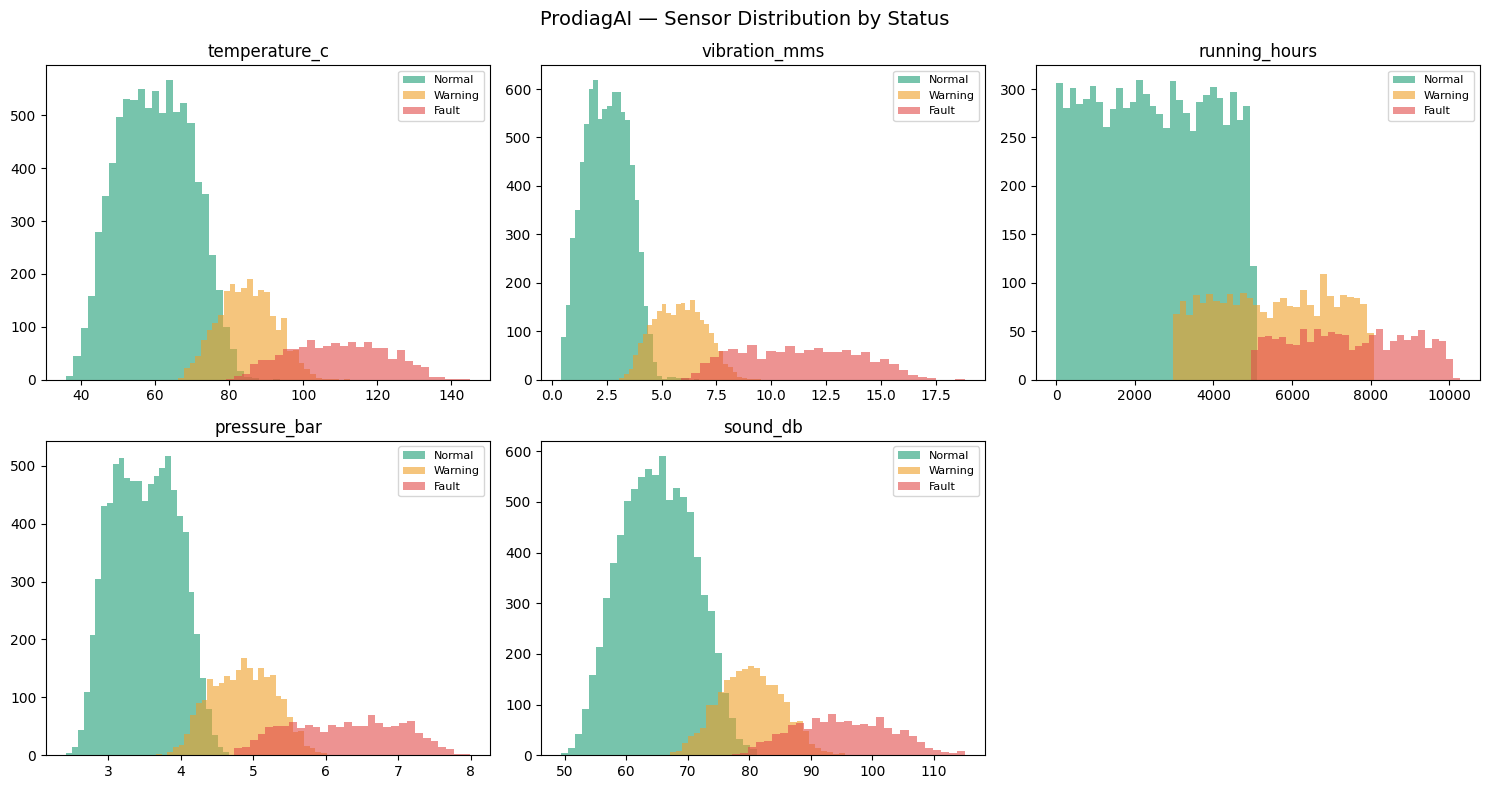

EDA plot saved


In [7]:
# EDA plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("ProdiagAI — Sensor Distribution by Status", fontsize=14)

sensors = ["temperature_c", "vibration_mms", "running_hours",
           "pressure_bar", "sound_db"]
colors  = {"Normal": "#1D9E75", "Warning": "#EF9F27", "Fault": "#E24B4A"}

for i, sensor in enumerate(sensors):
    ax = axes[i//3][i%3]
    for status, color in colors.items():
        subset = df[df["status"] == status][sensor]
        ax.hist(subset, bins=30, alpha=0.6, label=status, color=color)
    ax.set_title(sensor)
    ax.legend(fontsize=8)

axes[1][2].axis("off")
plt.tight_layout()
plt.savefig("../reports/eda_sensor_distributions.png", dpi=150)
plt.show()
print("EDA plot saved")

In [8]:
# Encode & prepare features
le_type   = LabelEncoder()
le_id     = LabelEncoder()
le_status = LabelEncoder()

df["machine_type_enc"] = le_type.fit_transform(df["machine_type"])
df["machine_id_enc"]   = le_id.fit_transform(df["machine_id"])
df["status_enc"]       = le_status.fit_transform(df["status"])

FEATURES = [
    "temperature_c", "vibration_mms", "running_hours",
    "pressure_bar", "sound_db",
    "machine_type_enc", "machine_id_enc"
]

X = df[FEATURES]
y = df["status_enc"]

print(f"Features: {FEATURES}")
print(f"Classes:  {list(le_status.classes_)}")
print(f"X shape:  {X.shape}")

Features: ['temperature_c', 'vibration_mms', 'running_hours', 'pressure_bar', 'sound_db', 'machine_type_enc', 'machine_id_enc']
Classes:  ['Fault', 'Normal', 'Warning']
X shape:  (12000, 7)


In [9]:
# Train/test split + scale + SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

print(f"Train: {X_train.shape[0]} → After SMOTE: {X_train_sm.shape[0]}")
print(f"Test:  {X_test.shape[0]} rows (no SMOTE)")
print(f"\nAfter SMOTE class balance:")
counts = pd.Series(y_train_sm).value_counts().sort_index()
for i, c in enumerate(le_status.classes_):
    print(f"  {c}: {counts[i]}")

Train: 8400 → After SMOTE: 17664
Test:  3600 rows (no SMOTE)

After SMOTE class balance:
  Fault: 5888
  Normal: 5888


In [10]:
# Train XGBoost (Initial)
xgb = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, random_state=42,
    eval_metric="mlogloss", verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)
xgb_preds = xgb.predict(X_test_sc)

print("=" * 50)
print("XGBoost — Classification Report")
print("=" * 50)
print(classification_report(
    y_test, xgb_preds,
    target_names=le_status.classes_
))

# CV score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb, X_train_sm, y_train_sm,
    cv=cv, scoring="f1_weighted"
)
print(f"CV F1 (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

XGBoost — Classification Report
              precision    recall  f1-score   support

       Fault       1.00      0.99      1.00       361
      Normal       1.00      1.00      1.00      2524
     Warning       1.00      1.00      1.00       715

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600

CV F1 (5-fold): 0.999 ± 0.000


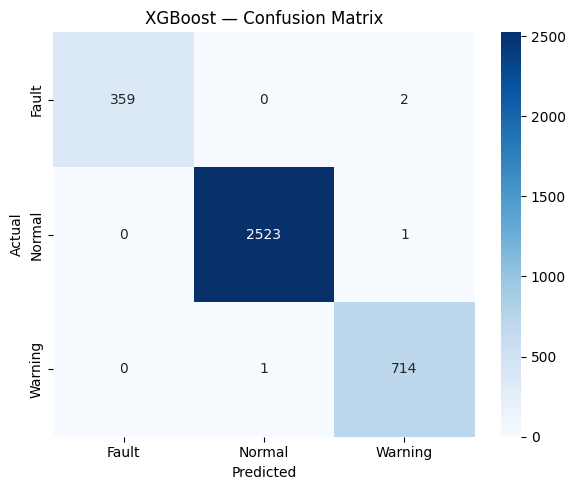

In [11]:
# Confusion matrix
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le_status.classes_,
    yticklabels=le_status.classes_
)
plt.title("XGBoost — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix_xgb.png", dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

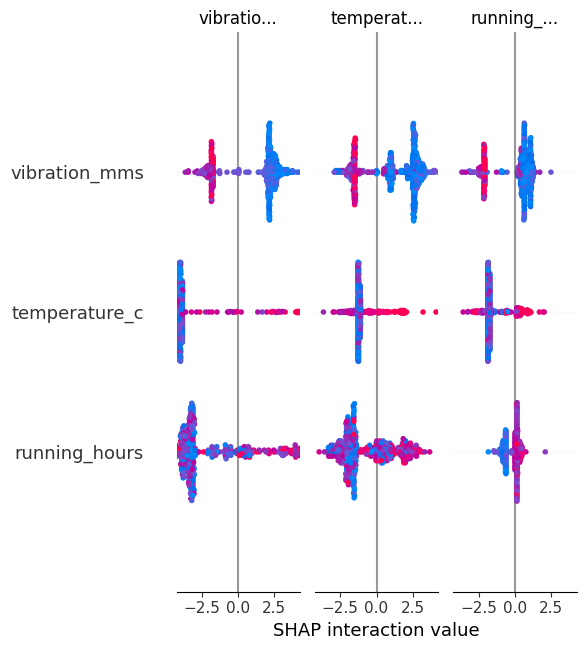

SHAP plot saved


In [12]:
# SHAP feature importance
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sc[:500])

plt.figure()
shap.summary_plot(
    shap_values, X_test_sc[:500],
    feature_names=FEATURES,
    class_names=list(le_status.classes_),
    show=False
)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved")

In [13]:
# Save all artefacts
with open("../models/xgb_model.pkl", "wb") as f: pickle.dump(xgb, f)
with open("../models/scaler.pkl",    "wb") as f: pickle.dump(scaler, f)
with open("../models/label_enc.pkl", "wb") as f: pickle.dump(le_status, f)
with open("../models/type_enc.pkl",  "wb") as f: pickle.dump(le_type, f)
with open("../models/id_enc.pkl",    "wb") as f: pickle.dump(le_id, f)

print("All artefacts saved to models/")
print("\nFiles saved:")
for f in os.listdir("../models"):
    print(f"  {f}")

All artefacts saved to models/

Files saved:
  id_enc.pkl
  label_enc.pkl
  scaler.pkl
  type_enc.pkl
  xgb_model.pkl


In [14]:
# Quick prediction test (verify pkl works)
with open("../models/xgb_model.pkl", "rb") as f: model_loaded = pickle.load(f)
with open("../models/scaler.pkl",    "rb") as f: scaler_loaded = pickle.load(f)
with open("../models/label_enc.pkl", "rb") as f: le_loaded = pickle.load(f)

# Test sample 
sample = pd.DataFrame([{
    "temperature_c": 110, "vibration_mms": 12.0, "running_hours": 7500,
    "pressure_bar": 6.0,  "sound_db": 92,
    "machine_type_enc": 0, "machine_id_enc": 0
}])

sample_sc = scaler_loaded.transform(sample)
pred_enc  = model_loaded.predict(sample_sc)
pred_prob = model_loaded.predict_proba(sample_sc)
pred_label = le_loaded.inverse_transform(pred_enc)[0]

print(f"Test prediction:  {pred_label}")
print(f"Confidence:       {pred_prob.max()*100:.1f}%")

Test prediction:  Fault
Confidence:       100.0%


In [15]:
# Train all 3 classifiers and compare
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

results = {}

# XGBoost (just record)
results["XGBoost"] = {
    "preds": xgb_preds,
    "f1_weighted": f1_score(y_test, xgb_preds, average="weighted"),
    "f1_fault":    f1_score(y_test, xgb_preds, average=None)[list(le_status.classes_).index("Fault")],
    "f1_warning":  f1_score(y_test, xgb_preds, average=None)[list(le_status.classes_).index("Warning")],
    "f1_normal":   f1_score(y_test, xgb_preds, average=None)[list(le_status.classes_).index("Normal")],
    "accuracy":    accuracy_score(y_test, xgb_preds),
}

# Random Forest 
print("Training Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
rf_time = time.time() - t0
rf_preds = rf.predict(X_test_sc)

results["Random Forest"] = {
    "preds": rf_preds,
    "f1_weighted": f1_score(y_test, rf_preds, average="weighted"),
    "f1_fault":    f1_score(y_test, rf_preds, average=None)[list(le_status.classes_).index("Fault")],
    "f1_warning":  f1_score(y_test, rf_preds, average=None)[list(le_status.classes_).index("Warning")],
    "f1_normal":   f1_score(y_test, rf_preds, average=None)[list(le_status.classes_).index("Normal")],
    "accuracy":    accuracy_score(y_test, rf_preds),
}

#  Logistic Regression
print("Training Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_time = time.time() - t0
lr_preds = lr.predict(X_test_sc)

results["Logistic Regression"] = {
    "preds": lr_preds,
    "f1_weighted": f1_score(y_test, lr_preds, average="weighted"),
    "f1_fault":    f1_score(y_test, lr_preds, average=None)[list(le_status.classes_).index("Fault")],
    "f1_warning":  f1_score(y_test, lr_preds, average=None)[list(le_status.classes_).index("Warning")],
    "f1_normal":   f1_score(y_test, lr_preds, average=None)[list(le_status.classes_).index("Normal")],
    "accuracy":    accuracy_score(y_test, lr_preds),
}

print("\nAll models trained!")

Training Random Forest...
Training Logistic Regression...

All models trained!


In [16]:
# comparison table
print("=" * 65)
print(f"{'Model':<22} {'Accuracy':>9} {'F1 Weighted':>12} {'F1 Fault':>10} {'F1 Warning':>11} {'F1 Normal':>10}")
print("=" * 65)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>9.4f} {r['f1_weighted']:>12.4f} {r['f1_fault']:>10.4f} {r['f1_warning']:>11.4f} {r['f1_normal']:>10.4f}")
print("=" * 65)

print("\nDetailed reports:")
for name, r in results.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, r["preds"], target_names=le_status.classes_))

Model                   Accuracy  F1 Weighted   F1 Fault  F1 Warning  F1 Normal
XGBoost                   0.9989       0.9989     0.9972      0.9972     0.9996
Random Forest             0.9997       0.9997     1.0000      0.9993     0.9998
Logistic Regression       0.9994       0.9994     0.9972      0.9986     1.0000

Detailed reports:

--- XGBoost ---
              precision    recall  f1-score   support

       Fault       1.00      0.99      1.00       361
      Normal       1.00      1.00      1.00      2524
     Warning       1.00      1.00      1.00       715

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600


--- Random Forest ---
              precision    recall  f1-score   support

       Fault       1.00      1.00      1.00       361
      Normal       1.00      1.00      1.00      2524
     Warning       1.00      1.00      1.00       715

    accuracy          

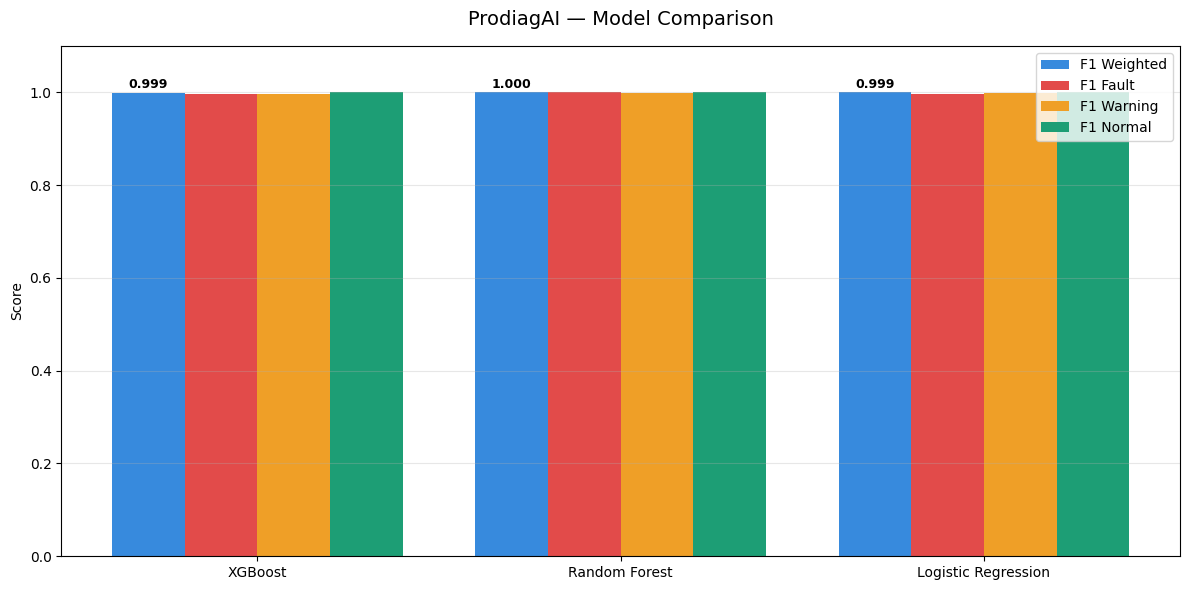

Comparison chart saved → reports/model_comparison.png


In [18]:
# Visual comparison chart
models     = list(results.keys())
f1_w       = [results[m]["f1_weighted"] for m in models]
f1_fault   = [results[m]["f1_fault"]    for m in models]
f1_warning = [results[m]["f1_warning"]  for m in models]
f1_normal  = [results[m]["f1_normal"]   for m in models]

x     = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width*1.5, f1_w,       width, label="F1 Weighted", color="#378ADD")
ax.bar(x - width*0.5, f1_fault,   width, label="F1 Fault",    color="#E24B4A")
ax.bar(x + width*0.5, f1_warning, width, label="F1 Warning",  color="#EF9F27")
ax.bar(x + width*1.5, f1_normal,  width, label="F1 Normal",   color="#1D9E75")

ax.set_title("ProdiagAI — Model Comparison", fontsize=14, pad=15)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(f1_w):
    ax.text(i - width*1.5, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150)
plt.show()
print("Comparison chart saved → reports/model_comparison.png")

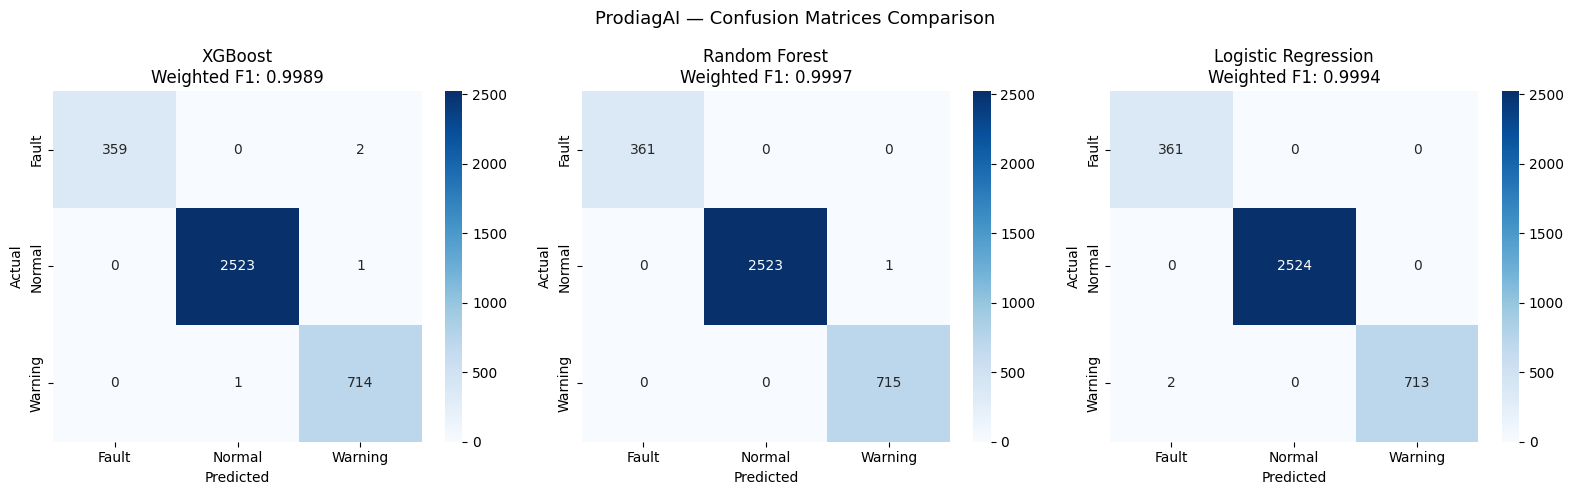

Saved → reports/confusion_matrices_all.png


In [19]:
# Confusion matrices for all 3 side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ProdiagAI — Confusion Matrices Comparison", fontsize=13)

model_preds = {
    "XGBoost":             xgb_preds,
    "Random Forest":       rf_preds,
    "Logistic Regression": lr_preds
}

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le_status.classes_,
        yticklabels=le_status.classes_,
        ax=ax
    )
    f1 = f1_score(y_test, preds, average="weighted")
    ax.set_title(f"{name}\nWeighted F1: {f1:.4f}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../reports/confusion_matrices_all.png", dpi=150)
plt.show()
print("Saved → reports/confusion_matrices_all.png")

In [20]:
# Winner decision + save best model
best_model_name = max(results, key=lambda m: results[m]["f1_fault"])
print("=" * 50)
print(f"WINNER based on Fault F1 score: {best_model_name}")
print(f"Fault F1:    {results[best_model_name]['f1_fault']:.4f}")
print(f"Weighted F1: {results[best_model_name]['f1_weighted']:.4f}")
print(f"Accuracy:    {results[best_model_name]['accuracy']:.4f}")
print("=" * 50)
print("\nReasoning: Fault class F1 is the most critical metric.")
print("Missing a Fault = machine breakdown. Must minimise false negatives.")

# XGBoost pkl already saved from Day 3 — nothing to change
print("\nmodel.pkl already saved — app.py continues to use XGBoost")

WINNER based on Fault F1 score: Random Forest
Fault F1:    1.0000
Weighted F1: 0.9997
Accuracy:    0.9997

Reasoning: Fault class F1 is the most critical metric.
Missing a Fault = machine breakdown. Must minimise false negatives.

model.pkl already saved — app.py continues to use XGBoost
